# 1. Data Loading & Sentiment Labeling

In this section, we load the raw employee message data and perform sentiment labeling. Each message is classified as **Positive**, **Neutral**, or **Negative** using the sentiment labeling module. The labeled data is saved for downstream analysis and further processing.

In [1]:
print("1. Sentiment Labeling")
from scripts import sentiment_labeling
sentiment_labeling.run_sentiment_labeling()

1. Sentiment Labeling
Labeled Data Preview:
                                             subject  \
0  going to work for the revenue model for mid & ...   
1       Phone Screen  Interview - Shannon L. Burnham   
2                              RE: My new work email   
3                                                Bet   
4                                          RE: Favor   

                                             message        date  \
0                                                NaN   7/29/2010   
1  When: Wednesday, June 06, 2001 10:00 AM-11:00 ...   7/25/2011   
2  we were thinking papasitos (we can meet somewh...   3/25/2010   
3  Since you never gave me the $20 for the last t...   5/21/2011   
4  sure, just call me the bank that delivers. we ...  10/23/2011   

                      from sentiment  sentiment_score  
0      eric.bass@enron.com   Neutral                0  
1     sally.beck@enron.com   Neutral                0  
2  johnny.palmer@enron.com  Negative      

# 2. Exploratory Data Analysis (EDA) & Visualization

We now explore the structure and content of our data. This includes:
- Inspecting the dataset shape and columns,
- Checking for missing values,
- Visualizing the distribution of sentiment labels,
- Analyzing message volume per employee,
- Investigating trends in sentiment over time,
- Exploring message length distributions and potential outliers.

Observations and insights from these analyses will inform the next steps.

2. EDA & Visualization
Number of bad dates: 43
Shape: (2125, 4)
Columns: ['subject', 'message', 'date', 'from']
<class 'pandas.core.frame.DataFrame'>
Index: 2125 entries, 0 to 2167
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   subject  2121 non-null   object        
 1   message  2081 non-null   object        
 2   date     2125 non-null   datetime64[ns]
 3   from     2125 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 83.0+ KB
None
                                             subject  \
0  going to work for the revenue model for mid & ...   
1       Phone Screen  Interview - Shannon L. Burnham   
2                              RE: My new work email   
3                                                Bet   
4                                          RE: Favor   

                                             message       date  \
0                                               

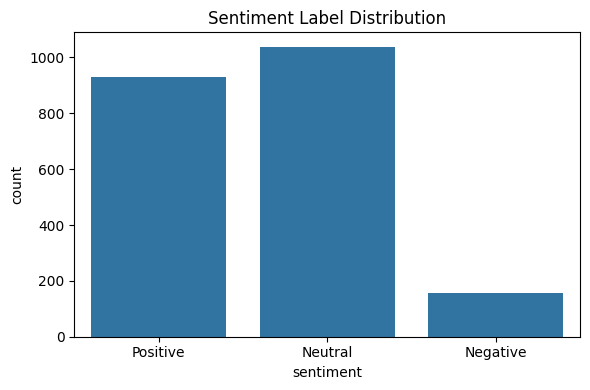


Top 10 senders by message count:
from
lydia.delgado@enron.com     279
john.arnold@enron.com       243
sally.beck@enron.com        220
johnny.palmer@enron.com     211
bobette.riner@enron.com     210
patti.thompson@enron.com    210
don.baughman@enron.com      210
eric.bass@enron.com         207
rhonda.denton@enron.com     168
kayne.coulter@enron.com     167
Name: count, dtype: int64


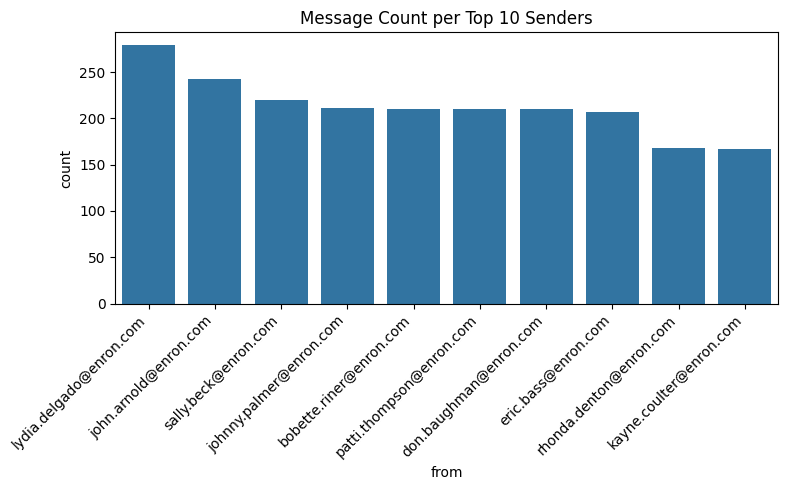


Monthly sentiment table:
sentiment   Negative  Neutral  Positive
year_month                             
2011-08            3       48        38
2011-09            3       38        50
2011-10            6       35        42
2011-11            6       37        45
2011-12            8       47        38


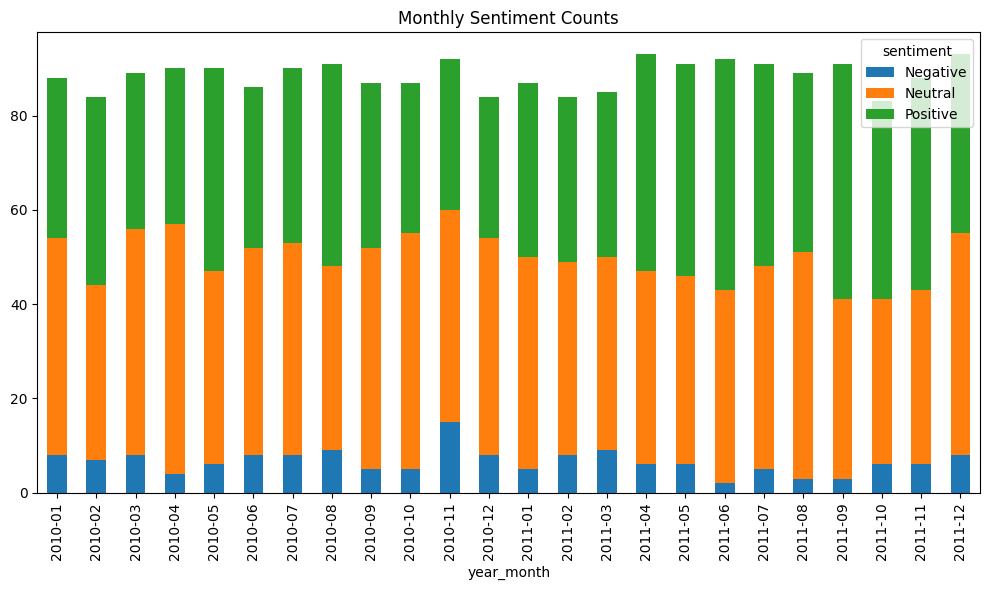

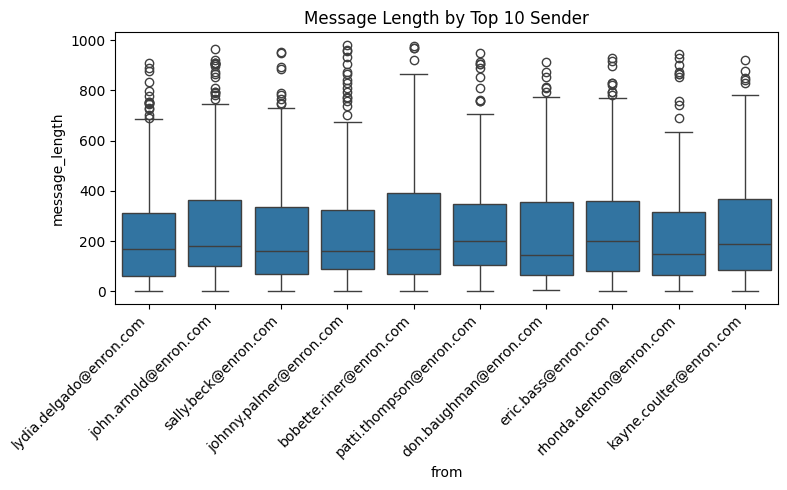

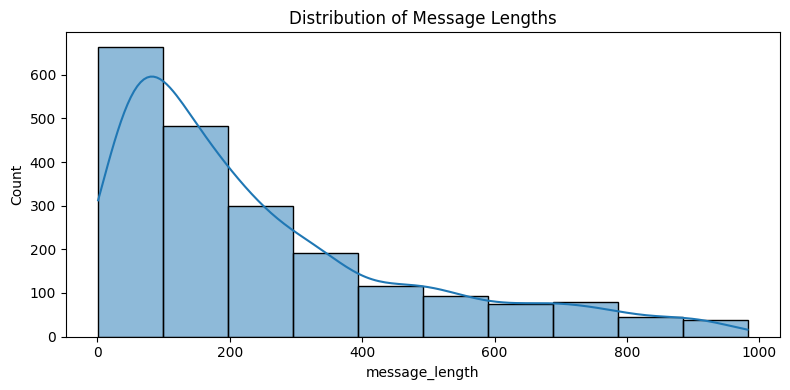


Unusually long messages (above 95th percentile):
                         from       date  \
8     kayne.coulter@enron.com 2010-02-06   
53        eric.bass@enron.com 2011-05-18   
73       sally.beck@enron.com 2011-03-07   
115   lydia.delgado@enron.com 2010-04-18   
120    don.baughman@enron.com 2010-06-13   
...                       ...        ...   
2008  rhonda.denton@enron.com 2010-08-06   
2030    john.arnold@enron.com 2011-02-12   
2044  bobette.riner@enron.com 2011-11-01   
2070  rhonda.denton@enron.com 2010-05-01   
2109      eric.bass@enron.com 2010-05-04   

                                                message  message_length  
8     The start time for Tuesday morning has been ch...           843.0  
53    Currently, members of Ted Murphy's group have ...           916.0  
73    In an effort to protect Enron's e-mail system ...           950.0  
115   [IMAGE] Dear Don: Heading back home for the ho...           833.0  
120   Klein High School Bearkadettes 2000 Golf Tour

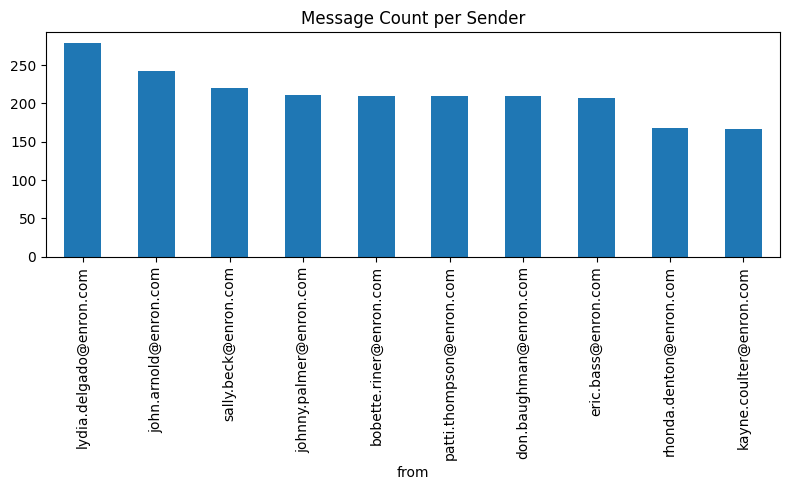


Largest gaps between messages by sender (days):
from
bobette.riner@enron.com     28.0
don.baughman@enron.com      33.0
eric.bass@enron.com         29.0
john.arnold@enron.com       24.0
johnny.palmer@enron.com     33.0
kayne.coulter@enron.com     35.0
lydia.delgado@enron.com     36.0
patti.thompson@enron.com    43.0
rhonda.denton@enron.com     28.0
sally.beck@enron.com        32.0
Name: days_since_last, dtype: float64

Senders with only one message: []

Senders with only one subject: []


In [2]:
print("2. EDA & Visualization")
from scripts import eda_visualization
eda_visualization.run_eda_visualization()

# 3. Employee Monthly Sentiment Score Calculation

Here, we compute a monthly sentiment score for each employee, assigning:
- **+1** for Positive messages,
- **–1** for Negative messages,
- **0** for Neutral messages.

Scores are aggregated by employee and by month, with each new month starting a fresh tally. This scoring provides the basis for employee ranking and risk evaluation.

In [3]:
print("3. Employee Score Calculation")
from scripts import employee_score
employee_score.run_employee_score()


3. Employee Score Calculation


,employee_id,year_month,monthly_score
0,bobette.riner@enron.com,2010-01,2
1,bobette.riner@enron.com,2010-02,5
2,bobette.riner@enron.com,2010-03,4
3,bobette.riner@enron.com,2010-04,1
4,bobette.riner@enron.com,2010-05,1
...,...,...,...
233,sally.beck@enron.com,2011-08,6
234,sally.beck@enron.com,2011-09,1
235,sally.beck@enron.com,2011-10,4
236,sally.beck@enron.com,2011-11,3


# 4. Employee Ranking

Using the monthly sentiment scores computed earlier, we rank employees based on their overall or recent sentiment trends. This ranking helps spotlight top performers and identify employees who may require additional support or engagement.

4. Employee Ranking


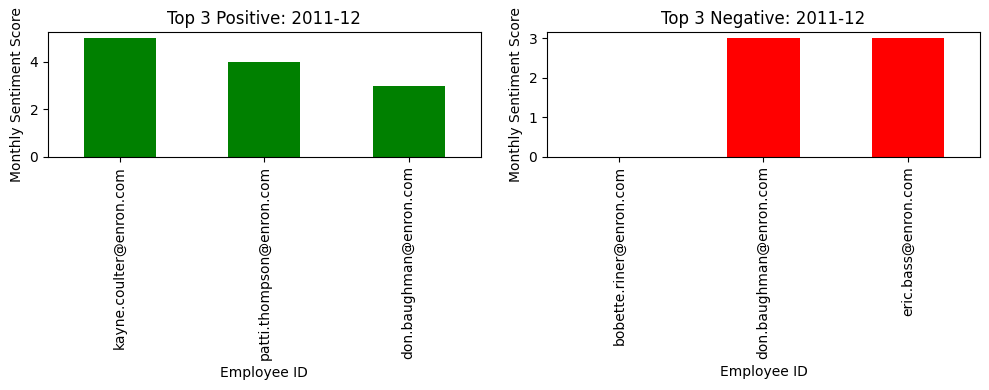


Month: 2010-01
Top 3 Positive Employees:
             employee_id  monthly_sentiment_score
 kayne.coulter@enron.com                        6
patti.thompson@enron.com                        5
  don.baughman@enron.com                        3
Top 3 Negative Employees:
            employee_id  monthly_sentiment_score
johnny.palmer@enron.com                        0
rhonda.denton@enron.com                        0
bobette.riner@enron.com                        2

Month: 2010-02
Top 3 Positive Employees:
            employee_id  monthly_sentiment_score
  john.arnold@enron.com                        7
 don.baughman@enron.com                        6
bobette.riner@enron.com                        5
Top 3 Negative Employees:
             employee_id  monthly_sentiment_score
 lydia.delgado@enron.com                        1
patti.thompson@enron.com                        1
    sally.beck@enron.com                        1

Month: 2010-03
Top 3 Positive Employees:
            employee_id  month

In [4]:
print("4. Employee Ranking")
from scripts import employee_ranking
employee_ranking.run_employee_ranking()

# 5. Flight Risk Detection

In this step, we analyze employee sentiment trajectories to flag individuals who may be at risk of leaving the organization. Criteria include consistent negative sentiment, sharp downward shifts, or other patterns of concern. Identified at-risk employees are highlighted for further attention.

5. Flight Risk Detection
Flight risk employees: ['bobette.riner@enron.com', 'johnny.palmer@enron.com', 'lydia.delgado@enron.com', 'sally.beck@enron.com']


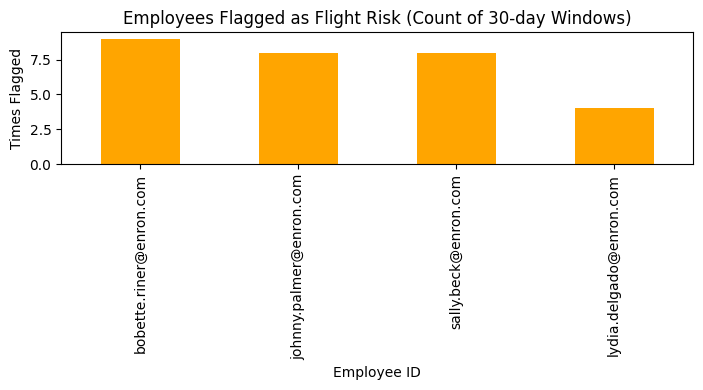

['bobette.riner@enron.com',
 'johnny.palmer@enron.com',
 'lydia.delgado@enron.com',
 'sally.beck@enron.com']

In [5]:
print("5. Flight Risk Detection")
from scripts import flight_risk
flight_risk.run_flight_risk()

# 6. Predictive Modeling

Leveraging the engineered features and sentiment scores, we build and evaluate predictive models to anticipate flight risk or changes in employee engagement. Model performance is assessed, and the most influential factors are discussed.

6. Predictive Modeling
MSE: 4.597150411062569
R2 Score: 0.5024270894401204


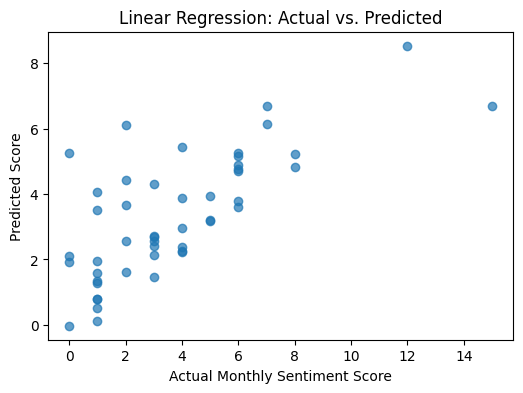


Linear Regression Model Interpretation
----------------------------------------
Intercept (baseline sentiment score): -0.41882700595800104
Coefficient for message_length: -0.0037 (negative influence)
Coefficient for word_count: 0.0364 (positive influence)
Coefficient for message_count: 0.3441 (positive influence)

Interpretation:
The intercept represents the baseline monthly sentiment score when all features are zero.
Each coefficient represents the expected change in the predicted sentiment score for a one-unit increase in the corresponding feature, holding other features constant.
Positive coefficients indicate a positive influence on sentiment score, while negative coefficients indicate a negative influence.
The magnitude of the coefficient indicates the strength of the association between the feature and the sentiment score.


In [6]:
print("6. Predictive Modeling")
from scripts import predictive_model
predictive_model.run_predictive_model()

# 7. Observations & Conclusions

**Observations:**  
- After performing the analysis, we expect to find trends in employee sentiment over time and across different individuals.
- Visualization of sentiment distributions often reveals whether the overall mood is positive, neutral, or negative.
- Employees with consistently negative sentiment scores may require further attention from HR to address underlying issues.
- Outlier analysis (long/short messages) can also point to unusual communication patterns.

**Conclusions:**  
- This workflow enables systematic sentiment analysis and scoring of employees based on their communications.
- The monthly sentiment scoring and ranking provide a foundation for identifying top performers, as well as those who may be at risk of disengagement or flight.
- The methods and visualizations outlined here can be extended for predictive modeling and proactive HR intervention.
- Future work could include refining sentiment analysis, incorporating additional features (such as message context or topic), and implementing automated alerts for at-risk employees.

*Note: As this project evolves, specific findings and recommendations will be added based on actual data and model results.*